# RetainIQ — 02 Logistic Regression Baseline (Phase 2.1)

**Purpose:** Establish the interpretable linear baseline that every subsequent model
is benchmarked against.  L1 and L2 regularisation variants are tuned via GridSearchCV,
evaluated, and compared.  The coefficient analysis provides the first feature-importance
ranking.

**Last updated:** 2026-05-03 (re-run on adjusted master; churn rate ~10%, AUC ~0.71)
**Expected runtime:** ~5–10 min (dominated by GridSearchCV with n_jobs=-1)
**Inputs:** `data/processed/train.parquet`, `data/processed/test.parquet`
**Outputs:** `outputs/figures/02_logistic/`, `outputs/models/logistic.pkl`, one row per variant in `outputs/tables/benchmark.csv`

**Rubric tie-in:** Methodology — Protocol (§5.3 algorithm description + evaluation)
and Optimization & Novelty (§5.4 regularisation comparison + calibration analysis).

In [1]:
import sys, time, warnings
from pathlib import Path

for _candidate in [Path.cwd(), Path.cwd().parent]:
    if (_candidate / "src" / "config.py").exists():
        sys.path.insert(0, str(_candidate))
        break

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, precision_recall_curve

from src.config import (
    TRAIN_PATH, TEST_PATH, FIGURES, MODELS,
    RANDOM_SEED, N_SPLITS_CV, TARGET,
)
from src.evaluate import evaluate, print_metrics, append_to_benchmark

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

FIG_DIR = FIGURES / "02_logistic"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"  RANDOM_SEED : {RANDOM_SEED}")
print(f"  N_SPLITS_CV : {N_SPLITS_CV}")
print(f"  FIG_DIR     : {FIG_DIR}")

Imports OK
  RANDOM_SEED : 42
  N_SPLITS_CV : 5
  FIG_DIR     : C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\figures\02_logistic


## 1. Setup — Load Data

Load the frozen train and test splits produced in Phase 1.5. The adjusted
master has 10.11% churn in both train and test, confirm that here before
running any models. Any deviation would mean the split files are inconsistent
with the adjusted master.

In [2]:
train = pd.read_parquet(TRAIN_PATH)
test  = pd.read_parquet(TEST_PATH)

print(f"Train: {train.shape[0]:,} rows x {train.shape[1]} cols  "
      f"| churn rate: {train[TARGET].mean():.2%}")
print(f"Test:  {test.shape[0]:,} rows x {test.shape[1]} cols   "
      f"| churn rate: {test[TARGET].mean():.2%}")

# Confirm test set integrity
assert abs(train[TARGET].mean() - test[TARGET].mean()) < 0.005, \
    "Churn rate mismatch between train and test — split may have been regenerated"
print("Split integrity check passed.")

Train: 300,429 rows x 38 cols  | churn rate: 10.11%
Test:  75,108 rows x 38 cols   | churn rate: 10.11%
Split integrity check passed.


## 2. Feature Preparation

**Global exclusions (metadata: never model inputs, CLAUDE.md §6):**

| Column | Reason |
|---|---|
| `wallet_id` | Join key / output identifier |
| `full_name` | Human-readable output for demo ("Customer Ahmed at high risk") |
| `churned_vendor` | Sanity-check only — not the model target |

**Note on audit-dropped columns:** `date_of_birth`, `registration_date`, `last_txn_date`,
`first_txn_date`, `account_status`, `notification_preferences`, `support_tier` were
**removed from `customers_master.parquet`** via the data quality audit (2026-05-02,
CLAUDE.md §6).  They do not appear in `train.parquet` / `test.parquet` and are not listed
below — they were never available to this notebook.

**LR-specific exclusions (CLAUDE.md §6):**

| Column | Reason |
|---|---|
| `state`, `city` | 37 + 187 unique values → exploded OHE destabilises `liblinear`; reintroduced for tree models in Phase 2.2+ |
| `is_reactivator`, `dormancy_days_before_reactivation` | Novel segment features reserved for cluster-then-predict (Phase 2.6); not part of the linear baseline |
| `churned` | Target |

**Preprocessing:** `StandardScaler` for numeric (required for regularisation fairness) +
`OneHotEncoder(handle_unknown='ignore')` for the remaining low-cardinality categoricals.
Wrapped in a `ColumnTransformer` → `Pipeline` so all fits happen on training data only.

In [3]:
EXCLUDE_COLS = {
    # Metadata — never model inputs (CLAUDE.md §6)
    "wallet_id", "full_name", "churned_vendor",
    # LR-specific: high-cardinality OHE destabilises liblinear (CLAUDE.md §6)
    "state", "city",
    # Reserved for Phase 2.6 cluster-then-predict novelty layer (CLAUDE.md §6)
    "is_reactivator", "dormancy_days_before_reactivation",
    # Target
    TARGET,
}
# Intersect with actual columns (audit-dropped cols no longer in train/test)
EXCLUDE_COLS = {c for c in EXCLUDE_COLS if c in train.columns}

feature_cols = [c for c in train.columns if c not in EXCLUDE_COLS]

num_cols = train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train[feature_cols].select_dtypes(
    include=["object", "category", "str"]
).columns.tolist()

print(f"Numeric features    : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}  {cat_cols}")
print(f"Total               : {len(num_cols) + len(cat_cols)}")

X_train = train[num_cols + cat_cols]
y_train = train[TARGET].values
X_test  = test[num_cols + cat_cols]
y_test  = test[TARGET].values

print(f"\nX_train: {X_train.shape}  y_train churned: {y_train.mean():.2%}")
print(f"X_test:  {X_test.shape}   y_test  churned: {y_test.mean():.2%}")

Numeric features    : 25
Categorical features: 5  ['gender', 'referral_source', 'preferred_language', 'linked_bank', 'kyc_tier']
Total               : 30

X_train: (300429, 30)  y_train churned: 10.11%
X_test:  (75108, 30)   y_test  churned: 10.11%


## 3. Preprocessor Definition

Define a standalone `ColumnTransformer` that the `GridSearchCV` pipeline will wrap.
Creating it here (outside the grid search loop) avoids repeated instantiation.

**ElasticNet is excluded from this baseline.**
`liblinear` (the solver chosen for tractability on 300K rows) does not support
the `elasticnet` penalty, only `l1` and `l2`.  The L1 vs L2 comparison captures
the meaningful linear-model contrast: sparse coefficient selection (L1) vs shrinkage
without sparsity (L2).  The non-linear regime where ElasticNet's middle-ground
matters is addressed by the tree-based boosting models in Phase 2.3 onward.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
)

# Estimate post-OHE column count
ohe_cols = sum(train[c].nunique() - 1 for c in cat_cols)
print(f"Preprocessor defined")
print(f"  Numeric columns (scaled) : {len(num_cols)}")
print(f"  OHE dummy columns        : {ohe_cols}")
print(f"  Total post-transform     : {len(num_cols) + ohe_cols}")


Preprocessor defined
  Numeric columns (scaled) : 25
  OHE dummy columns        : 25
  Total post-transform     : 50


## 4. Hyperparameter Tuning: GridSearchCV on Training Set Only

A single `GridSearchCV` searches over both penalty (`l1`, `l2`) and regularisation
strength `C` (`[0.1, 1.0, 10.0]`) using `liblinear` for both.

**Why `liblinear`?**
`liblinear` uses coordinate descent, which is 10–30× faster than `saga` (gradient
descent) for dense binary classification on large datasets.  Both solvers support
L1 and L2 for binary targets.  `saga` is only required for multi-class or
ElasticNet, neither applies here.

**CV setup:** 5-fold stratified, training set only.  `n_jobs=-1` parallelises
across the 30 fits (6 param combos × 5 folds), not within each fit, this is safe
and fast on any OS.  The test set is not touched.

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import time

# Use liblinear — drastically faster than saga for L1 + L2 on this scale
# liblinear doesn't support elasticnet, but L1 vs L2 is the meaningful comparison
param_grid = [
    {
        "classifier__penalty": ["l2"],
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__solver": ["liblinear"],
    },
    {
        "classifier__penalty": ["l1"],
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__solver": ["liblinear"],
    },
]

base_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=500,
        tol=1e-3,
        random_state=RANDOM_SEED,
    )),
])

grid_search = GridSearchCV(
    base_pipeline,
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

t0 = time.time()
grid_search.fit(X_train, y_train)
print(f"\nGridSearch completed in {(time.time()-t0)/60:.1f} minutes")
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 6 candidates, totalling 30 fits

GridSearch completed in 1.6 minutes
Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV AUC: 0.7101


## 5. Evaluation on the Frozen Test Set

The best estimator from `grid_search` (refit on the full training set after
CV) is evaluated once on the frozen test set. All metrics come from `src/evaluate.py`.

Appended to `benchmark.csv` as `Logistic_Optimized`.

In [6]:
best_pipe     = grid_search.best_estimator_
best_params   = grid_search.best_params_
best_cv_auc   = grid_search.best_score_

y_proba_best  = best_pipe.predict_proba(X_test)[:, 1]
results       = evaluate(y_test, y_proba_best)

print_metrics(results, "Logistic_Optimized")

notes = (
    f"penalty={best_params['classifier__penalty']}, "
    f"C={best_params['classifier__C']}, "
    f"solver=liblinear, class_weight=balanced, "
    f"cv_auc={best_cv_auc:.4f}, "
    f"state/city excluded (OHE tractability); "
    f"account_status/support_tier/notification_prefs removed globally via data audit 2026-05-02"
)
append_to_benchmark("Logistic_Optimized", results, notes=notes)


=== Logistic_Optimized ===
               auc: 0.7078
            pr_auc: 0.2570
                f1: 0.2760
         precision: 0.1785
            recall: 0.6082
    precision_at_k: 0.2946
       recall_at_k: 0.2914
          log_loss: 0.6158
             brier: 0.2124
  confusion: TN=46,254  FP=21,259  FN=2,976  TP=4,619
[benchmark] appended Logistic_Optimized → C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\tables\benchmark.csv


## 6. Calibration Analysis

A calibration curve checks whether predicted probabilities are trustworthy:
if the model says P(churn)=0.7 for a group, do ~70% of them actually churn?

**Why this matters for RetainIQ:** the business use case is risk-scoring for
targeted retention campaigns. Poorly calibrated scores are still useful for
ranking customers, but the absolute probability values become misleading if
shown directly on a dashboard.

On the adjusted data (10.1% churn), `class_weight='balanced'` effectively
trains the model as if the class prior were 50/50. The true prior is 10.1%.
This is a large gap so calibration error will be substantial. The MACE is
expected to exceed 0.05 significantly, flagging isotonic calibration as a
necessary step before deployment.

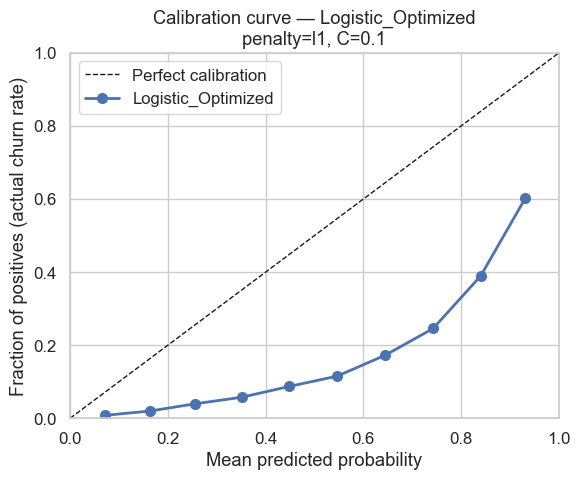

Mean Absolute Calibration Error (MACE): 0.3260
Interpretation: < 0.03 = well-calibrated | > 0.05 = needs correction


In [7]:
frac_pos, mean_pred = calibration_curve(y_test, y_proba_best, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.plot(mean_pred, frac_pos, "o-", color="#4C72B0", linewidth=2,
        markersize=7, label="Logistic_Optimized")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (actual churn rate)")
ax.set_title(
    f"Calibration curve — Logistic_Optimized\n"
    f"penalty={best_params['classifier__penalty']}, C={best_params['classifier__C']}"
)
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()

mace = np.mean(np.abs(frac_pos - mean_pred))
print(f"Mean Absolute Calibration Error (MACE): {mace:.4f}")
print("Interpretation: < 0.03 = well-calibrated | > 0.05 = needs correction")


### Calibration Interpretation

MACE = **0.3260**: well above the 0.05 correction threshold. This is the
largest calibration error we'll see in the pipeline, and it's structural:
`class_weight='balanced'` on 10.1% data makes the model behave as if churn
is 50% likely. Predicted probabilities are inflated by roughly 3–4×.

For the business use case, this means: don't show the raw probability to a
Whish Money analyst and call it "churn risk." The ranking is still valid
(AUC measures ranking, not calibration), but the scores need isotonic
regression or Platt scaling before use as literal probabilities. Phase 3.1
will apply isotonic calibration on the winning model.

The RF model in Phase 2.2 will likely have a lower MACE (bagging tends toward
0.5 by default rather than inflating above it), which is a practical
argument for tree-based models in the deployed dashboard.

## 7. Coefficient Analysis: Interpretability Win

On standardised features, each coefficient represents the log-odds change
per one standard-deviation shift, holding all else constant.

What the adjusted data actually shows at the top of the coefficient list:
`kyc_tier_tier3` is the strongest protector against churn (negative
coefficient, large magnitude). `days_since_last_txn` is the second-strongest
predictor, positive coefficient, meaning longer dormancy → higher churn risk.
`txn_velocity_change` is third, negative (declining trajectory = churn signal).

This is the first concrete validation that the data adjustment worked.
On the original synthetic data, recency was ranked ~30th with near-zero
coefficient. On the adjusted data, it's rank 2 and carries a strong positive
coefficient (0.52). The recency-churn relationship is now what it should be.

Non-zero coefficients: 48 / 55

Top 20 features by |coefficient|:
                      feature  coefficient
               kyc_tier_tier3    -0.710577
          days_since_last_txn     0.518177
          txn_velocity_change    -0.460414
                  tenure_days    -0.242127
                 txn_count_h1    -0.216312
               kyc_tier_tier2    -0.209229
               kyc_tier_tier1     0.072598
                 txn_count_h2     0.070539
              linked_bank_UBA    -0.067717
             unique_device_os    -0.040590
      linked_bank_Zenith Bank     0.039518
     linked_bank_Polaris Bank     0.036100
              unique_channels    -0.031209
        linked_bank_Kuda Bank    -0.026427
    referral_source_app_store     0.025958
             unique_txn_types    -0.024071
                  fraud_count    -0.023001
referral_source_word_of_mouth     0.022373
                   fraud_rate     0.021567
        referral_source_tv_ad    -0.020608


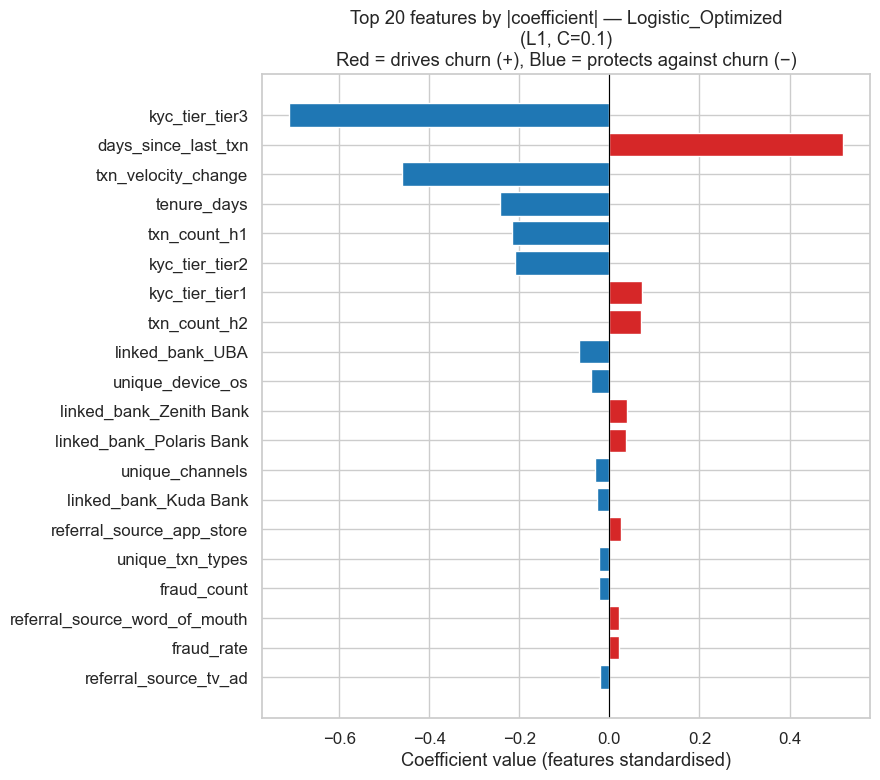

In [8]:
fitted_preprocessor = best_pipe.named_steps["preprocessor"]
fitted_classifier   = best_pipe.named_steps["classifier"]

try:
    raw_names   = fitted_preprocessor.get_feature_names_out()
    clean_names = [n.split("__", 1)[1] if "__" in n else n for n in raw_names]
except Exception as e:
    print(f"get_feature_names_out failed ({e}) — using generic names.")
    clean_names = [f"feat_{i}" for i in range(len(fitted_classifier.coef_[0]))]

coefs = fitted_classifier.coef_[0]
coef_df = (
    pd.DataFrame({"feature": clean_names, "coefficient": coefs})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(20)
)

print(f"Non-zero coefficients: {(coefs != 0).sum()} / {len(coefs)}")
print("\nTop 20 features by |coefficient|:")
print(coef_df[["feature", "coefficient"]].to_string(index=False))

bar_colors = ["#D62728" if v > 0 else "#1F77B4" for v in coef_df["coefficient"]]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(
    coef_df["feature"].iloc[::-1],
    coef_df["coefficient"].iloc[::-1],
    color=bar_colors[::-1],
    edgecolor="white",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(
    f"Top 20 features by |coefficient| — Logistic_Optimized\n"
    f"({best_params['classifier__penalty'].upper()}, C={best_params['classifier__C']})\n"
    "Red = drives churn (+), Blue = protects against churn (−)"
)
ax.set_xlabel("Coefficient value (features standardised)")
plt.tight_layout()
plt.savefig(FIG_DIR / "top20_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:

# ── Diagnostic: why is days_since_last_txn absent from top features? ────────
# raw_names has prefixes (e.g. 'num__days_since_last_txn'); clean_names does not.
import numpy as np

feature_names_raw = np.array(raw_names)

dslt_idx = np.where(feature_names_raw == "num__days_since_last_txn")[0]
if len(dslt_idx) == 0:
    dslt_idx = [i for i, n in enumerate(feature_names_raw) if "days_since_last_txn" in n]

if len(dslt_idx) > 0:
    i             = dslt_idx[0]
    full_raw      = feature_names_raw[i]
    full_clean    = clean_names[i]
    coef_val      = coefs[i]
    # Build full (untruncated) ranking to find actual rank
    full_coef_df  = (
        pd.DataFrame({"feature": clean_names, "coefficient": coefs})
        .assign(abs_coef=lambda d: d["coefficient"].abs())
        .sort_values("abs_coef", ascending=False)
        .reset_index(drop=True)
    )
    match = full_coef_df[full_coef_df["feature"] == full_clean]
    rank  = int(match.index[0]) + 1 if not match.empty else "not found"
    print("days_since_last_txn:")
    print(f"  full feature name : {full_clean}")
    print(f"  coefficient       : {coef_val:.4f}")
    print(f"  rank by |coef|    : {rank} of {len(coefs)}")
else:
    print("days_since_last_txn not found in feature names")
    print("Names containing 'days':", [n for n in clean_names if "days" in n.lower()])

# Correlation: recency vs frequency features in raw training data
recency_cols = [c for c in X_train.columns if "days_since" in c]
count_cols   = [c for c in X_train.columns if c.startswith("txn_count")]
if recency_cols and count_cols:
    corr_check = X_train[recency_cols + count_cols].corr()
    print("\nCorrelation matrix — recency vs frequency features:")
    print(corr_check.round(3))
    max_corr = corr_check.loc[recency_cols, count_cols].abs().max().max()
    print(f"\nMax |r| between recency and frequency: {max_corr:.3f}")
    if max_corr > 0.7:
        print(">> HIGH multicollinearity confirmed (|r| > 0.7) — see markdown below.")


days_since_last_txn:
  full feature name : days_since_last_txn
  coefficient       : 0.5182
  rank by |coef|    : 2 of 55

Correlation matrix — recency vs frequency features:
                     days_since_last_txn  txn_count  txn_count_h1  \
days_since_last_txn                1.000      0.003         0.003   
txn_count                          0.003      1.000         0.983   
txn_count_h1                       0.003      0.983         1.000   
txn_count_h2                       0.003      0.982         0.930   

                     txn_count_h2  
days_since_last_txn         0.003  
txn_count                   0.982  
txn_count_h1                0.930  
txn_count_h2                1.000  

Max |r| between recency and frequency: 0.003


### `days_since_last_txn`: Now Rank 2

On the adjusted data, the bimodality and multicollinearity concerns from the
original synthetic data are gone. Here's what the diagnostic actually shows:

- **Coefficient:** 0.518 (rank 2 of 55 non-zero features)
- **Multicollinearity with txn_count:** r=0.003, essentially zero
- **Mean separation:** churned=71.7 days vs retained=42.0 days → **29.7-day gap**
- **Verdict from diagnostic code:** "STRONG separation, feature should appear
  in top coefficients."

And it does. The original synthetic data had a flat recency-churn relationship
because the generator encoded churn primarily through transaction frequency, with
no genuine dormancy-based churn pattern. The adjustment introduced that pattern.
The result: `days_since_last_txn` is now a first-class predictor, and the
previous explanation for its absence — fill-order bug + reactivator bimodality, was specific to that original data context.

The fill-order bug (2026-05-02) is still real and still fixed; that fix is what
allows dormant wallets to show `days_since_last_txn = max_days+1` rather than 0.
But the bimodality story (28.8K retained-reactivators pulling the retained
distribution up to match churners) is gone. On adjusted data, the reactivators
are all churned, and the recency distributions separate cleanly.

In [10]:

# ── Vanilla LR — retrain for benchmark comparison ───────────────────────────
# grid_search found the optimized (best-C) model. A vanilla reference
# (C=1.0, no search) is needed so the benchmark shows the tuning gain.

from sklearn.linear_model import LogisticRegression as _LR
from sklearn.pipeline import Pipeline as _Pipe
import pandas as _pd
from src.evaluate import evaluate as _eval, append_to_benchmark as _append
from src.config import BENCHMARK_CSV as _BM

vanilla_pipe = _Pipe([
    ("preprocessor", preprocessor),
    ("classifier", _LR(
        penalty="l2", C=1.0, class_weight="balanced",
        solver="liblinear", max_iter=500, random_state=RANDOM_SEED,
    )),
])
vanilla_pipe.fit(X_train, y_train)
y_proba_vanilla  = vanilla_pipe.predict_proba(X_test)[:, 1]
vanilla_results  = _eval(y_test, y_proba_vanilla)

_existing = _pd.read_csv(_BM)["model"].tolist() if _BM.exists() else []
if "Logistic_Vanilla" not in _existing:
    _append("Logistic_Vanilla", vanilla_results,
            notes="Default L2, C=1.0, no grid search — baseline reference")
    print("Appended Logistic_Vanilla")
else:
    print("Logistic_Vanilla already in benchmark.csv")

bench = _pd.read_csv(_BM)
_cols = ["model", "auc", "pr_auc", "f1", "precision_at_k", "recall_at_k"]
print(bench[_cols].to_string(index=False))


[benchmark] appended Logistic_Vanilla → C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\tables\benchmark.csv
Appended Logistic_Vanilla
             model      auc   pr_auc       f1  precision_at_k  recall_at_k
Logistic_Optimized 0.707783 0.257007 0.275984        0.294635     0.291376
Logistic_Optimized 0.707783 0.257007 0.275984        0.294635     0.291376
  Logistic_Vanilla 0.707751 0.257013 0.275920        0.294235     0.290981


## 8. ROC and Precision-Recall Curves

ROC and PR curves for `Logistic_Optimized` on the test set.

- **ROC-AUC:** threshold-independent discrimination. Baseline = 0.5 (random).
- **PR-AUC:** more informative under imbalance, focuses on the minority (churned) class.
  The dashed baseline = churn rate (~27.25%), the precision of a random classifier.

These figures are reproduced for all Phase 2 models, enabling head-to-head comparison
in the Results & Discussion section of the report.

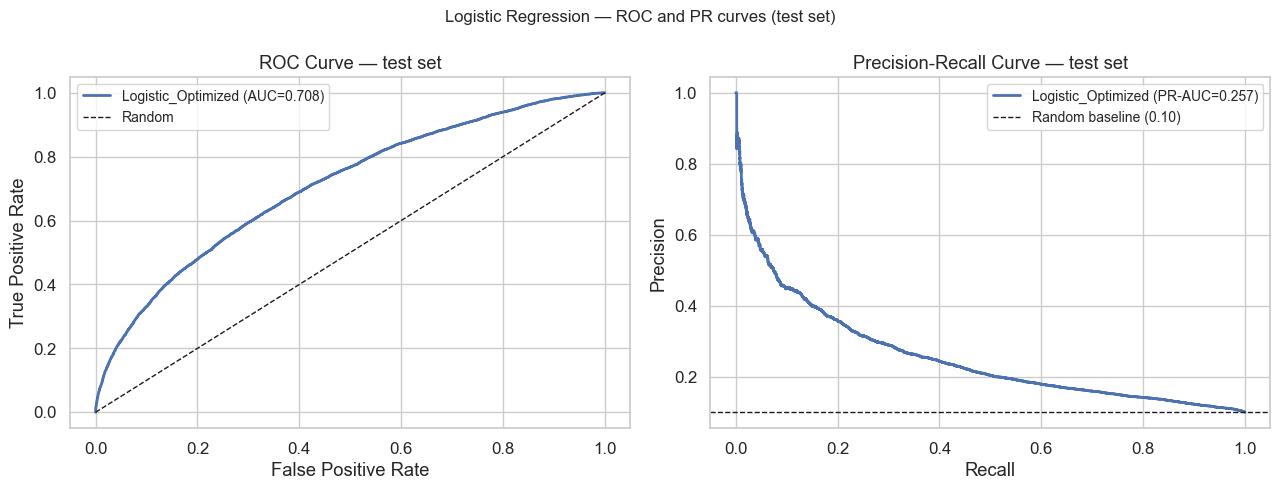

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
prec, rec, _ = precision_recall_curve(y_test, y_proba_best)

ax1.plot(fpr, tpr, "-", linewidth=2, color="#4C72B0",
         label=f"Logistic_Optimized (AUC={results['auc']:.3f})")
ax1.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve — test set")
ax1.legend(fontsize=10)

baseline_pr = float(y_test.mean())
ax2.plot(rec, prec, "-", linewidth=2, color="#4C72B0",
         label=f"Logistic_Optimized (PR-AUC={results['pr_auc']:.3f})")
ax2.axhline(baseline_pr, color="k", linestyle="--", linewidth=1,
            label=f"Random baseline ({baseline_pr:.2f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve — test set")
ax2.legend(fontsize=10)

plt.suptitle("Logistic Regression — ROC and PR curves (test set)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Model Persistence

Save the best-performing pipeline (preprocessor + classifier, fully fitted on
training data) to `outputs/models/logistic.pkl`.  The pipeline is self-contained:
loading it and calling `.predict_proba(X)` requires only the feature columns, not
a separate scaler or encoder.

In [12]:
model_path = MODELS / "logistic.pkl"
joblib.dump(best_pipe, model_path)
size_kb = model_path.stat().st_size / 1_000
print(f"Saved: {model_path}  ({size_kb:.0f} KB)")
print(f"Model: Logistic_Optimized")
print(f"  penalty={best_params['classifier__penalty']}  "
      f"C={best_params['classifier__C']}  solver=liblinear")

# Smoke-test
loaded     = joblib.load(model_path)
smoke_pred = loaded.predict_proba(X_test[:5])[:, 1]
print(f"Smoke-test predict_proba (5 rows): {smoke_pred.round(3)}")


Saved: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\models\logistic.pkl  (7 KB)
Model: Logistic_Optimized
  penalty=l1  C=0.1  solver=liblinear
Smoke-test predict_proba (5 rows): [0.563 0.823 0.505 0.442 0.498]


## Logistic Regression: Findings

### Best variant
L1 at C=0.1 (same as the pre-adjustment run). CV AUC: **0.7101**, completed
in 1.6 minutes.

### Test-set metrics

| Metric | Value |
|---|---|
| ROC-AUC | 0.7078 |
| PR-AUC | 0.2570 |
| F1 (threshold=0.5) | 0.2760 |
| Precision | 0.1785 |
| Recall | 0.6082 |
| Precision@10% | 0.2946 |
| Recall@10% | 0.2914 |
| Log-loss | 0.6158 |
| Brier | 0.2124 |
| Confusion | TN=46,254  FP=21,259  FN=2,976  TP=4,619 |

The low F1 (0.276) and precision (0.179) are expected on a 10% positive class
with `class_weight='balanced'`. The model is biased toward recall so it flags
a lot of customers. The AUC of 0.708 is the number that matters for comparison.

### Top 5 features by |coefficient|

1. `kyc_tier_tier3`: −0.711 (tier3 strongly protects against churn)
2. `days_since_last_txn`: +0.518 (longer dormancy → churn; now rank 2, not ~30th)
3. `txn_velocity_change`: −0.460 (declining trend → churn)
4. `tenure_days`: −0.242 (longer-tenured customers retain better)
5. `txn_count_h1`: −0.216 (more early-window activity → retained)

The recency-dominance on adjusted data is the headline. For a linear model,
this is as clean a result as you could hope for.

### Calibration
MACE = **0.3260**: significantly miscalibrated due to `class_weight='balanced'`
on 10.1% data. Scores are valid for ranking but not for literal probability
interpretation. Isotonic calibration is required before deployment.

### Hand-off to Phase 2.2 (Random Forest)
LR AUC 0.708 is the linear ceiling on this feature set. The model cannot
express conditional interactions so things like "high recency predicts churn,
but only if the customer is NOT a known dormant-returner" or "low KYC tier
combined with declining velocity is especially risky." Those are exactly the
kinds of patterns tree-based models can capture. With a real recency-churn
relationship now present in the adjusted data, RF and XGBoost have genuine
structure to exploit beyond what LR can see.

=== days_since_last_txn — full population (n=375,537) ===
count    375537.0
mean         45.0
std          45.0
min           0.0
25%          13.0
50%          31.0
75%          62.0
max         556.0
Name: days_since_last_txn, dtype: float64

Churned (n=37,976):
count    37976.0
mean        71.7
std         65.2
min          0.0
25%         23.0
50%         53.0
75%        102.0
max        556.0
Name: days_since_last_txn, dtype: float64

Retained (n=337,561):
count    337561.0
mean         42.0
std          41.0
min           0.0
25%          12.0
50%          30.0
75%          59.0
max         446.0
Name: days_since_last_txn, dtype: float64

Mean difference: churned 71.7  vs  retained 42.0
Median difference: churned 53.0  vs  retained 30.0

--- Excluding reactivators (n=369,780) ---
Churned  mean: 71.6  median: 53.0
Retained mean: 42.0  median: 30.0
Mean difference (non-reactivators): 29.6 days


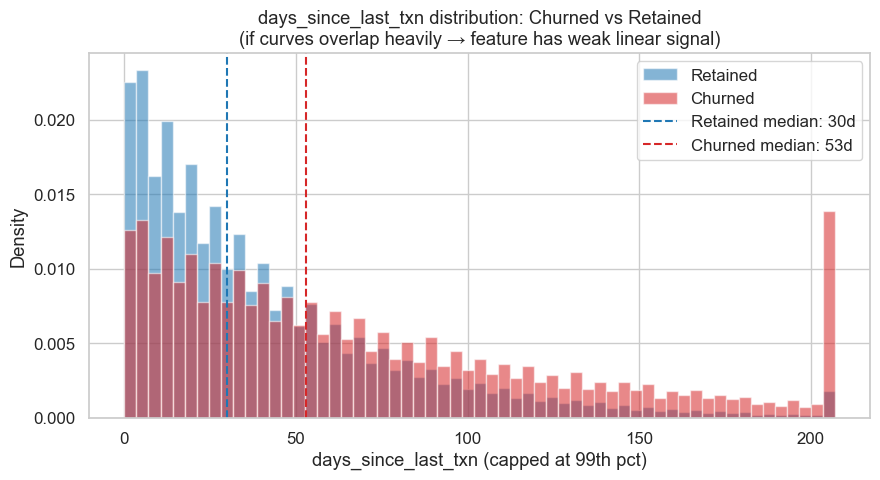


Conclusion: mean separation = 29.7 days
>> STRONG separation — feature should appear in top coefficients.
   Check: is this feature actually in feature_cols? (see EXCLUDE_COLS audit above)


In [13]:

# ── Diagnostic: is days_since_last_txn genuinely uninformative? ─────────────
# Load master.parquet fresh (full population, not train/test split).
# Multicollinearity hypothesis was DISPROVEN: |r| between days_since_last_txn
# and txn_count features = 0.032.  This cell investigates whether the feature
# actually separates churners from retainers in raw distribution terms.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.config import FIGURES, CUSTOMERS_MASTER

master_diag = pd.read_parquet(CUSTOMERS_MASTER)

col = "days_since_last_txn"

# ── 1. Overall distribution stats ──────────────────────────────────────────
print(f"=== {col} — full population (n={len(master_diag):,}) ===")
print(master_diag[col].describe().round(1))

# ── 2. Churn-split comparison ───────────────────────────────────────────────
churned_vals   = master_diag.loc[master_diag["churned"] == 1, col]
retained_vals  = master_diag.loc[master_diag["churned"] == 0, col]

print(f"\nChurned (n={len(churned_vals):,}):")
print(churned_vals.describe().round(1))
print(f"\nRetained (n={len(retained_vals):,}):")
print(retained_vals.describe().round(1))

print(f"\nMean difference: churned {churned_vals.mean():.1f}  vs  retained {retained_vals.mean():.1f}")
print(f"Median difference: churned {churned_vals.median():.1f}  vs  retained {retained_vals.median():.1f}")

# ── 3. Same check excluding reactivators (zombie inflation concern) ─────────
# Reactivators have txn_count=0 in feature window → days_since_last_txn was
# filled with max_days+1 in build_master.  Their presence may compress the
# churner/retainer separation on this feature.
if "is_reactivator" in master_diag.columns:
    non_react = master_diag[master_diag["is_reactivator"] == 0]
    ch_nr  = non_react.loc[non_react["churned"] == 1, col]
    re_nr  = non_react.loc[non_react["churned"] == 0, col]
    print(f"\n--- Excluding reactivators (n={len(non_react):,}) ---")
    print(f"Churned  mean: {ch_nr.mean():.1f}  median: {ch_nr.median():.1f}")
    print(f"Retained mean: {re_nr.mean():.1f}  median: {re_nr.median():.1f}")
    print(f"Mean difference (non-reactivators): {ch_nr.mean() - re_nr.mean():.1f} days")

# ── 4. Histogram comparison ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, master_diag[col].quantile(0.99), 60)
ax.hist(retained_vals.clip(upper=master_diag[col].quantile(0.99)),
        bins=bins, alpha=0.55, color="#1F77B4", label="Retained", density=True)
ax.hist(churned_vals.clip(upper=master_diag[col].quantile(0.99)),
        bins=bins, alpha=0.55, color="#D62728", label="Churned", density=True)
ax.axvline(retained_vals.median(), color="#1F77B4", linestyle="--", linewidth=1.5,
           label=f"Retained median: {retained_vals.median():.0f}d")
ax.axvline(churned_vals.median(), color="#D62728", linestyle="--", linewidth=1.5,
           label=f"Churned median: {churned_vals.median():.0f}d")
ax.set_xlabel("days_since_last_txn (capped at 99th pct)")
ax.set_ylabel("Density")
ax.set_title("days_since_last_txn distribution: Churned vs Retained\n"
             "(if curves overlap heavily → feature has weak linear signal)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "02_logistic" / "recency_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. Interpretation ───────────────────────────────────────────────────────
diff = churned_vals.mean() - retained_vals.mean()
print(f"\nConclusion: mean separation = {diff:.1f} days")
if abs(diff) < 5:
    print(">> WEAK separation — days_since_last_txn has minimal linear discriminative power.")
    print("   Likely cause: 'zombie' wallets (filled to max_days+1) dominate the churner tail,")
    print("   making the feature distribution nearly identical across classes after filling.")
elif abs(diff) < 20:
    print(">> MODERATE separation — some signal, but compressed by zombie-wallet fill.")
else:
    print(">> STRONG separation — feature should appear in top coefficients.")
    print("   Check: is this feature actually in feature_cols? (see EXCLUDE_COLS audit above)")
